In [1]:
import requests

In [2]:
url  = "https://archive-api.open-meteo.com/v1/archive"
res = requests.get(url)

params = {
    "latitude": 30.3165,      # Dehradun, for example
    "longitude": 78.0322,
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "start_date" : "2015-01-01",
    "end_date" : "2024-12-31",
    "timezone": "auto"
}

res = requests.get(url, params=params)
print(res.status_code)
print(res.text[:300])  # peek at raw response first
json_data = res.json()

200
{"latitude":30.333918,"longitude":77.97186,"generationtime_ms":892.8362131118774,"utc_offset_seconds":19800,"timezone":"Asia/Kolkata","timezone_abbreviation":"GMT+5:30","elevation":652.0,"daily_units":{"time":"iso8601","temperature_2m_max":"°C","temperature_2m_min":"°C","precipitation_sum":"mm"},"da


In [3]:
import pandas as pd
daily_data = json_data["daily"]
df = pd.DataFrame(daily_data)
df["latitude"] = json_data["latitude"]
df['longitude'] = json_data['longitude']
df["timezone"] = json_data["timezone"]


In [4]:
df

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,latitude,longitude,timezone
0,2015-01-01,21.3,5.7,0.0,30.333918,77.97186,Asia/Kolkata
1,2015-01-02,14.5,9.6,13.5,30.333918,77.97186,Asia/Kolkata
2,2015-01-03,15.7,10.8,27.8,30.333918,77.97186,Asia/Kolkata
3,2015-01-04,15.6,8.0,3.0,30.333918,77.97186,Asia/Kolkata
4,2015-01-05,17.2,3.5,0.0,30.333918,77.97186,Asia/Kolkata
...,...,...,...,...,...,...,...
3648,2024-12-27,14.7,6.1,10.1,30.333918,77.97186,Asia/Kolkata
3649,2024-12-28,15.8,9.2,6.7,30.333918,77.97186,Asia/Kolkata
3650,2024-12-29,19.0,7.6,0.0,30.333918,77.97186,Asia/Kolkata
3651,2024-12-30,19.1,5.5,0.0,30.333918,77.97186,Asia/Kolkata


In [5]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                3653 non-null   object 
 1   temperature_2m_max  3653 non-null   float64
 2   temperature_2m_min  3653 non-null   float64
 3   precipitation_sum   3653 non-null   float64
 4   latitude            3653 non-null   float64
 5   longitude           3653 non-null   float64
 6   timezone            3653 non-null   object 
dtypes: float64(5), object(2)
memory usage: 199.9+ KB


In [6]:
import sqlite3

conn = sqlite3.connect("weather.db")

df.to_sql("daily_weather",conn,if_exists = "replace",index=False)

3653

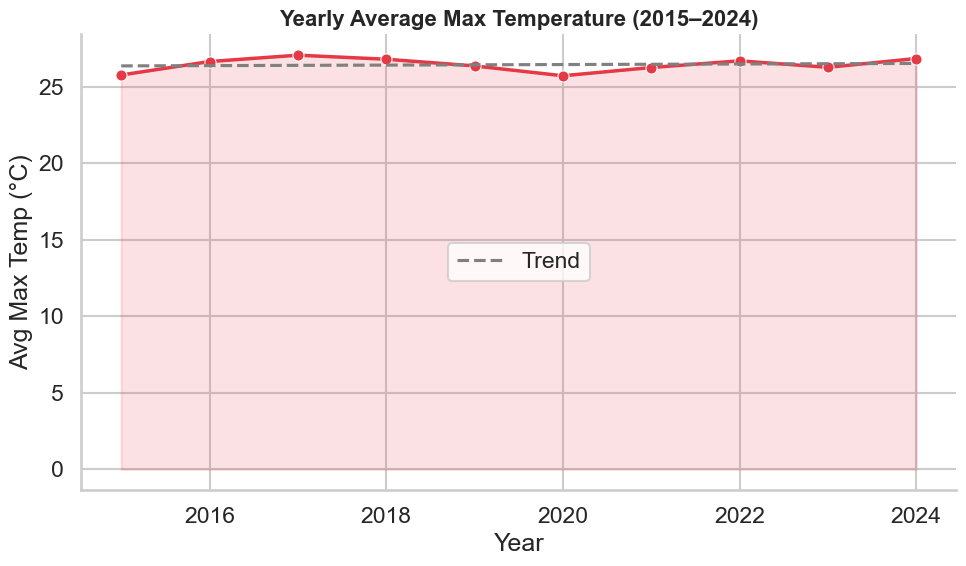

In [9]:
# Yearly average max temperature (SQLite version)
query = """
SELECT strftime('%Y', time) AS yr, AVG(temperature_2m_max) AS avg_max_temp
FROM daily_weather
GROUP BY yr
ORDER BY yr
"""
result = pd.read_sql(query, conn)
result["yr"] = result["yr"].astype(int)   # convert text year to integer — required for polyfit/plotting math

import numpy as np

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
sns.set_context("talk")

sns.lineplot(x="yr", y="avg_max_temp", data=result, color="#e63946", 
             marker='o', markersize=8, linewidth=2.5)

plt.fill_between(result["yr"], result["avg_max_temp"], alpha=0.15, color="#e63946")

z = np.polyfit(result["yr"], result["avg_max_temp"], 1)
p = np.poly1d(z)
plt.plot(result["yr"], p(result["yr"]), linestyle="--", color="gray", label="Trend")

plt.title("Yearly Average Max Temperature (2015–2024)", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Avg Max Temp (°C)")
sns.despine()
plt.legend()
plt.tight_layout()
plt.savefig("yearly_temp_trend.png", dpi=300, bbox_inches='tight')
plt.show()

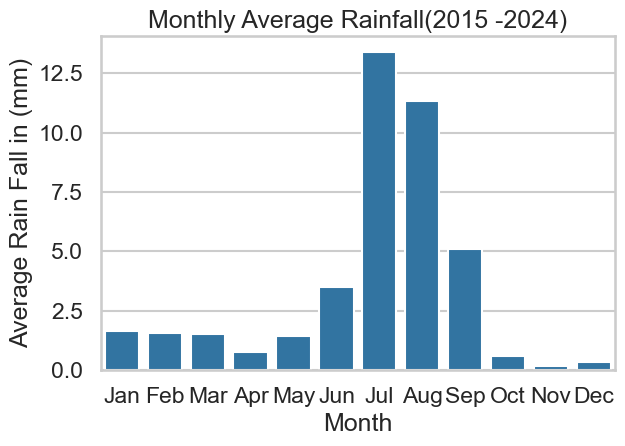

In [10]:
# Monthly rainfall comparison

query1 = """
SELECT strftime('%m', time) AS mo, AVG(precipitation_sum) AS avg_precip
FROM daily_weather
GROUP BY mo
ORDER BY mo
"""
result = pd.read_sql(query1, conn)

result["mo"] = result["mo"].astype(int)

month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
               7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}
result["month_names"] = result["mo"].map(month_names)

sns.barplot(
    data = result,
    x = "month_names",
    y = "avg_precip",
    order = list(month_names.values())
    
)

plt.xlabel("Month")
plt.ylabel("Average Rain Fall in (mm)")
plt.title("Monthly Average Rainfall(2015 -2024)")
plt.savefig("Monthly_average_Rainfall.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

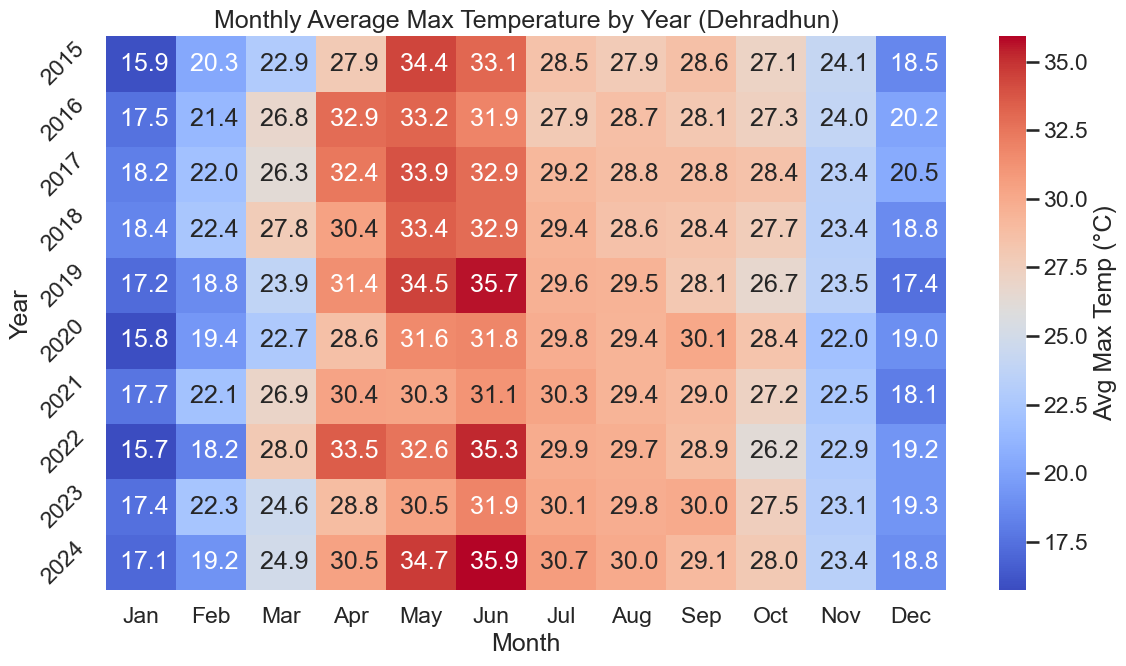

In [11]:
# Heat Map for Monthly Average Max Temperature year (2015 - 2024)

query = """
SELECT strftime('%Y', time) AS yr, strftime('%m', time) AS mo, AVG(temperature_2m_max) AS avg_max_temp
FROM daily_weather
GROUP BY yr, mo
ORDER BY yr, mo
"""
result = pd.read_sql(query, conn)

heatmap_data = result.pivot(index= "yr" , columns = "mo", values = "avg_max_temp")
heatmap_data.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize = (12,7))
sns.heatmap(
    heatmap_data ,
    annot = True,
    fmt= " .1f",
    cmap = "coolwarm",
    cbar_kws={'label': 'Avg Max Temp (°C)'}
)
plt.title("Monthly Average Max Temperature by Year (Dehradhun)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.yticks(rotation = 45)
plt.tight_layout()

plt.show()

In [12]:
df.to_csv("weathe_data.csv",index=False)